<a href="https://colab.research.google.com/github/norewyx0205/vlm-event-boundary/blob/main/notebooks/colab_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ladder Event Boundary Evaluation on Colab

This notebook keeps the baseline sanity-check evaluation and runs the 6-level ladder experiment with Qwen3-VL.


In [59]:
%cd /content
!ls

/content
sample_data  vlm-event-boundary


In [60]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["GH_TOKEN"] = userdata.get("GH_TOKEN")

## Clone or Update Repository

If the repository already exists in Colab, this cell pulls the latest code. If it does not exist, it clones the repo.


In [61]:
from getpass import getpass
import os

REPO_URL = "github.com/norewyx0205/vlm-event-boundary.git"
REPO_DIR = "/content/vlm-event-boundary"

if not os.path.exists(REPO_DIR):
    token = os.environ["GH_TOKEN"]
    if token:
        !git clone https://{token}@{REPO_URL} {REPO_DIR}
    else:
        !git clone https://{REPO_URL} {REPO_DIR}
else:
    print("Repository already exists; pulling latest changes...")
    %cd {REPO_DIR}
    !git pull --ff-only

# check repo version
!git -C /content/vlm-event-boundary rev-parse --short HEAD
!grep -n "subprocess.Popen" /content/vlm-event-boundary/notebooks/colab_eval.ipynb


Repository already exists; pulling latest changes...
/content/vlm-event-boundary
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 11 (delta 6), reused 11 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (11/11), 21.85 KiB | 1.21 MiB/s, done.
From https://github.com/norewyx0205/vlm-event-boundary
   4905417..d32352e  main       -> origin/main
Updating 4905417..d32352e
Fast-forward
 README.md                           |  36 ++++++--
 notebooks/colab_eval.ipynb          |  39 +++++++-
 scripts/analyze_attention_roi.py    |   6 +-
 scripts/probe_attention_roi.py      | 179 ++++++++++++++++++++++++++++++++++--
 tests/test_analyze_attention_roi.py |  12 +++
 tests/test_probe_attention_roi.py   |  33 +++++++
 6 files changed, 284 insertions(+), 21 deletions(-)
d32352e
98:            "8758:        \"    process = subprocess.Popen(\\n\",\n"
123:        "!grep -n \"subprocess.Popen\" /conten

In [62]:
%cd /content/vlm-event-boundary
!ls

/content/vlm-event-boundary
analysis			notebooks    scripts
baseline_boundary_videos	README.md    synthetic_boundary_videos
data				results      tests
generate_2d_boundary_videos.py	run_eval.py


## Install Dependencies

These packages are needed for Qwen video input, video generation, and result analysis.


In [63]:
%pip install "transformers==5.9.0" accelerate "qwen-vl-utils==0.0.14" "decord==0.6.0" opencv-python imageio-ffmpeg

import subprocess
import sys
subprocess_transformers = subprocess.check_output(
    [sys.executable, "-c", "import transformers; print(transformers.__version__)"],
    text=True,
).strip()
if subprocess_transformers != "5.9.0":
    raise RuntimeError(
        f"Expected subprocess transformers 5.9.0, found {subprocess_transformers}."
    )
print("Pinned Transformers subprocess runtime:", subprocess_transformers)

  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
Using cached transformers-5.9.0-py3-none-any.whl (10.8 MB)
Pinned Transformers subprocess runtime: 5.9.0


In [64]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    torch.set_default_device("cuda")


CUDA available: True


## Configuration

Qwen3-VL is the default model for the ladder experiment. You can change the model string here if needed.


In [65]:
MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"
MODEL_REVISION = "0c351dd01ed87e9c1b53cbc748cba10e6187ff3b"  # Qwen3-VL-8B-Instruct commit used for reproducible runs.
EVAL_SEED = 42
ATTN_IMPLEMENTATION = "eager"
RESULT_DIR = "/content/vlm-event-boundary/results"

BASELINE_ANNOTATION = "/content/vlm-event-boundary/baseline_boundary_videos/annotations.jsonl"
SYNTHETIC_ANNOTATION = "/content/vlm-event-boundary/synthetic_boundary_videos/annotations.jsonl"
LADDER_ROOT = "/content/vlm-event-boundary/data/ladder_v2"
DATASET_VERSION = "ladder_v2"

## Generate Baseline and Synthetic Reference Datasets

This regenerates the legacy simple baseline and the harder synthetic reference set. These are kept as reference points outside the 6-level ladder.

In [66]:
# Video generation is disabled for normal evaluation runs.
# Uncomment the next line when the baseline/synthetic datasets need to be regenerated.
# !python generate_2d_boundary_videos.py --dataset all

## Baseline Sanity Check

This keeps the earlier simple baseline. It should verify that Qwen3 can solve the easy before/after task.


In [67]:
from pathlib import Path

for name, annotation in [
    ("baseline", BASELINE_ANNOTATION),
    ("synthetic", SYNTHETIC_ANNOTATION),
]:
    path = Path(annotation)
    print(f"{name} annotation exists:", path.exists())
    if path.exists():
        print(f"{name} eval rows:", sum(1 for _ in open(path)))
        print(f"{name} videos:", len(list((path.parent / "videos").glob("*.mp4"))))
    else:
        print(f"{name} files not found; run the generation cell above.")

baseline annotation exists: True
baseline eval rows: 40
baseline videos: 20
synthetic annotation exists: True
synthetic eval rows: 240
synthetic videos: 120


In [68]:
!python scripts/run_eval.py \
  --annotation_path "$BASELINE_ANNOTATION" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name baseline_qwen3_sanity_check \
  --output_dir "$RESULT_DIR"

Loading weights: 100% 750/750 [00:05<00:00, 127.95it/s]

Running baseline_qwen3_sanity_check from /content/vlm-event-boundary/baseline_boundary_videos/annotations.jsonl
Processing baseline_001_low_boundary.mp4::prompt_original
qwen-vl-utils using torchcodec to read video.
baseline_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing baseline_001_low_boundary.mp4::prompt_swapped
baseline_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing baseline_002_low_boundary.mp4::prompt_original
baseline_002_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing baseline_002_low_boundary.mp4::prompt_swapped
baseline_002_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing baseline_003_low_boundary.mp4::prompt_original
baseline_003_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing baseline_003_low_boundary.mp4::prompt_swapped
baseline_003_low_boundary.mp4 pred= B correct= B is_correct= True

## Synthetic Hard Reference Evaluation

This evaluates the legacy harder synthetic set so it can be compared with the simple baseline and the ladder levels.

In [69]:
!python scripts/run_eval.py \
  --annotation_path "$SYNTHETIC_ANNOTATION" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name synthetic_qwen3_reference \
  --output_dir "$RESULT_DIR"

Loading weights: 100% 750/750 [00:05<00:00, 129.72it/s]

Running synthetic_qwen3_reference from /content/vlm-event-boundary/synthetic_boundary_videos/annotations.jsonl
Processing sample_001_low_boundary.mp4::prompt_original
qwen-vl-utils using torchcodec to read video.
sample_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing sample_001_low_boundary.mp4::prompt_swapped
sample_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing sample_002_low_boundary.mp4::prompt_original
sample_002_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing sample_002_low_boundary.mp4::prompt_swapped
sample_002_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing sample_003_low_boundary.mp4::prompt_original
sample_003_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing sample_003_low_boundary.mp4::prompt_swapped
sample_003_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing samp

## Generate 6-Level Ladder Dataset

This creates the 6-level `data/ladder_v2/level_*` dataset with evaluation-level mirrored annotations. Re-run this cell when generation parameters change.


In [70]:
# Video generation is disabled for normal evaluation runs.
# Uncomment this command block when the ladder dataset needs to be regenerated.
# !python scripts/generate_ladder_dataset.py \
#   --dataset_version "$DATASET_VERSION" \
#   --samples_per_level 30 \
#   --output_root "$LADDER_ROOT" \
#   --seed 42


## Check Ladder Dataset

Each level should contain 30 base samples × 4 boundary conditions × 2 mirrored prompts = 240 evaluation rows. The full ladder has 6 levels.


In [71]:
from pathlib import Path

for ann in sorted(Path(LADDER_ROOT).glob("level_*/annotations.jsonl")):
    video_count = len(list((ann.parent / "videos").glob("*.mp4")))
    row_count = sum(1 for _ in open(ann))
    print(ann.parent.name, "videos=", video_count, "eval_rows=", row_count)


level_1_simple videos= 120 eval_rows= 240
level_2_randomized videos= 120 eval_rows= 240
level_3_non_target_static_distractors videos= 120 eval_rows= 240
level_4_target_like_static_distractors videos= 120 eval_rows= 240
level_5_target_like_moving_distractors videos= 120 eval_rows= 240
level_6_hard_temporal_interference videos= 120 eval_rows= 240


## Qwen3 Ladder Smoke Test

Run a tiny subset before launching the full ladder evaluation.


In [72]:
!python scripts/run_eval.py \
  --annotation_path "$LADDER_ROOT/level_1_simple/annotations.jsonl" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name smoke_ladder_v2_level_1_simple_qwen3 \
  --output_dir "$RESULT_DIR" \
  --max_samples 4

Loading weights: 100% 750/750 [00:05<00:00, 132.93it/s]

Running smoke_ladder_v2_level_1_simple_qwen3 from /content/vlm-event-boundary/data/ladder_v2/level_1_simple/annotations.jsonl
Processing level_1_sample_001_low_boundary_original
qwen-vl-utils using torchcodec to read video.
level_1_sample_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing level_1_sample_001_low_boundary_swapped
level_1_sample_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing level_1_sample_001_temporal_boundary_original
level_1_sample_001_temporal_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing level_1_sample_001_temporal_boundary_swapped
level_1_sample_001_temporal_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'

Saved raw results to /content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/smoke_ladder_v2_level_1_simple_qwen3/20260831_133750/raw_results.jsonl
Saved summary to /content/vlm-event-boundary/results/Qwen_Qwen3-VL

## Run Qwen3 on All 6 Ladder Levels

This is the main ladder experiment. Results are saved under `results/<safe_model_name>/<dataset_name>/<timestamp>/`.


In [73]:
!python scripts/run_eval.py \
  --annotation_root "$LADDER_ROOT" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name_prefix "$DATASET_VERSION"_ \
  --output_dir "$RESULT_DIR"


Loading weights: 100% 750/750 [00:05<00:00, 133.86it/s]

Running ladder_v2_level_1_simple from /content/vlm-event-boundary/data/ladder_v2/level_1_simple/annotations.jsonl
Processing level_1_sample_001_low_boundary_original
qwen-vl-utils using torchcodec to read video.
level_1_sample_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing level_1_sample_001_low_boundary_swapped
level_1_sample_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing level_1_sample_001_temporal_boundary_original
level_1_sample_001_temporal_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing level_1_sample_001_temporal_boundary_swapped
level_1_sample_001_temporal_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing level_1_sample_001_visual_boundary_original
level_1_sample_001_visual_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing level_1_sample_001_visual_boundary_swapped
level_1_sample_001_visual_boundary.mp4 p

## Analyze Ladder Results

This aggregates all Qwen3 ladder runs and treats prompt Accuracy and Strict both-correct pair accuracy as co-primary metrics. It produces both 6-level curves, direct Accuracy-vs-Strict comparisons, paired boundary comparisons, and swap-consistency diagnostics.



In [74]:
ANALYSIS_DIR = f"analysis/{DATASET_VERSION}_ladder"

!python scripts/analyze_results.py \
  --input "$RESULT_DIR" \
  --dataset_name_prefix "ladder_v2_level_" \
  --output_dir "$ANALYSIS_DIR" \
  --plots

Analyzed 3360 rows from 14 raw result file(s).
Saved analysis to analysis/ladder_v2_ladder


## Inspect Saved Files


In [75]:
!find "$RESULT_DIR" -maxdepth 4 -type f | sort | tail -60
!find analysis -maxdepth 2 -type f | sort


/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_095641/config.json
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_095641/raw_results.jsonl
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_095641/summary.json
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_125734/config.json
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_125734/raw_results.jsonl
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_125734/summary.json
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_133812/config.json
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruct/ladder_v2_level_1_simple/20260831_133812/raw_results.jsonl
/content/vlm-event-boundary/results/Qwen_Qwen3-VL-8B-Instruc

## Level 5 Feature-Ablation Pilot

This pilot compares four structurally paired Level 5 variants: full, shape-only, color-only, and size-only. It also includes a separate size-only 2x2 stress pilot crossing absolute target size with distractor count.


In [76]:
ABLATION_VERSION = "l5_feature_ablation_v1"
ABLATION_ROOT = f"/content/vlm-event-boundary/data/{ABLATION_VERSION}"
ABLATION_ANALYSIS_DIR = f"/content/vlm-event-boundary/analysis/{ABLATION_VERSION}"
SIZE_STRESS_ROOT = f"{ABLATION_ROOT}/size_stress_pilot"
SIZE_STRESS_ANALYSIS_DIR = f"{ABLATION_ANALYSIS_DIR}_size_stress"
SIZE_CLEAR_CONTRAST_ROOT = f"{ABLATION_ROOT}/size_clear_contrast_pilot"
SIZE_CLEAR_CONTRAST_ANALYSIS_DIR = f"{ABLATION_ANALYSIS_DIR}_size_clear_contrast"
DIAGNOSTIC_ROOT = "/content/vlm-event-boundary/data/diagnostics"
SIZE_CLEAR_DIAGNOSTIC_ANNOTATION = f"{DIAGNOSTIC_ROOT}/l5_size_clear_contrast_diagnostics/annotations.jsonl"
SIZE_CLEAR_DIAGNOSTIC_ANALYSIS_DIR = f"{ABLATION_ANALYSIS_DIR}_size_clear_contrast_diagnostics"
PERTURBATION_ROOT = "/content/vlm-event-boundary/data/perturbations/l5_clear_small_many"
PERTURBATION_ANALYSIS_DIR = f"{ABLATION_ANALYSIS_DIR}_perturb_l5_clear_small_many"
ATTENTION_OUTPUT_PATH = "/content/vlm-event-boundary/analysis/attention/l5_clear_small_many_attention.json"
ATTENTION_VISUALIZATION_DIR = "/content/vlm-event-boundary/analysis/attention/l5_clear_small_many_figures"
ATTENTION_ANALYSIS_DIR = "/content/vlm-event-boundary/analysis/attention/l5_clear_small_many_metrics"
FEATURE_ATTENTION_OUTPUT_PATH = "/content/vlm-event-boundary/analysis/attention/l5_feature_calibration_attention.json"
FEATURE_ATTENTION_CASE_MANIFEST = "/content/vlm-event-boundary/analysis/attention/l5_feature_calibration_cases.jsonl"
FEATURE_ATTENTION_ANALYSIS_DIR = "/content/vlm-event-boundary/analysis/attention/l5_feature_calibration_metrics"
FEATURE_ATTENTION_BASE_SAMPLES = 4
FEATURE_ATTENTION_MAX_SAMPLES = FEATURE_ATTENTION_BASE_SAMPLES * 4 * 4 * 2
ABLATION_VARIANTS = ["L5_full", "L5_shape_only", "L5_color_only", "L5_size_only"]


### Generate And Validate Paired Stimuli


In [77]:
# Video generation is disabled for normal evaluation runs.
# Uncomment this command block when the L5 ablation dataset needs to be regenerated.
# !python scripts/generate_l5_feature_ablation.py \
#   --dataset_version "$ABLATION_VERSION" \
#   --samples_per_variant 30 \
#   --size_stress_samples_per_cell 10 \
#   --output_root "$ABLATION_ROOT" \
#   --seed 42
#
# !python scripts/check_l5_feature_ablation.py --root "$ABLATION_ROOT"


### Run Qwen3 Evaluation

Each variant retains all four boundary conditions and original/swapped mirrored prompts.


In [78]:
!python scripts/run_eval.py \
  --annotation_root "$ABLATION_ROOT" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name_prefix "$ABLATION_VERSION"_main_ \
  --output_dir "$RESULT_DIR"


Loading weights: 100% 750/750 [00:05<00:00, 130.92it/s]

Running l5_feature_ablation_v1_main_L5_color_only from /content/vlm-event-boundary/data/l5_feature_ablation_v1/L5_color_only/annotations.jsonl
Processing l5_color_only_sample_001_low_boundary_original
qwen-vl-utils using torchcodec to read video.
l5_color_only_sample_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing l5_color_only_sample_001_low_boundary_swapped
l5_color_only_sample_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing l5_color_only_sample_001_temporal_boundary_original
l5_color_only_sample_001_temporal_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing l5_color_only_sample_001_temporal_boundary_swapped
l5_color_only_sample_001_temporal_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing l5_color_only_sample_001_visual_boundary_original
l5_color_only_sample_001_visual_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Proce

### Run Size-Only 2x2 Stress Pilot

This evaluates 10 base samples in each of large/few, large/many, small/few, and small/many, for 320 prompt evaluations in total.


In [79]:
!python scripts/run_eval.py \
  --annotation_root "$SIZE_STRESS_ROOT" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name_prefix "$ABLATION_VERSION"_size_stress_ \
  --output_dir "$RESULT_DIR"


Loading weights: 100% 750/750 [00:05<00:00, 130.17it/s]

Running l5_feature_ablation_v1_size_stress_L5_size_only_large_few from /content/vlm-event-boundary/data/l5_feature_ablation_v1/size_stress_pilot/L5_size_only_large_few/annotations.jsonl
Processing l5_size_only_large_few_sample_001_low_boundary_original
qwen-vl-utils using torchcodec to read video.
l5_size_only_large_few_sample_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing l5_size_only_large_few_sample_001_low_boundary_swapped
l5_size_only_large_few_sample_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing l5_size_only_large_few_sample_001_temporal_boundary_original
l5_size_only_large_few_sample_001_temporal_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing l5_size_only_large_few_sample_001_temporal_boundary_swapped
l5_size_only_large_few_sample_001_temporal_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing l5_size_only_large_few_sample_

### Analyze Feature, Boundary, And Position Effects

The analysis uses the latest run for each variant and writes prompt accuracy, strict mirrored-pair accuracy, the accuracy-strict gap `d`, position-sensitive pair rates, paired comparisons, swap consistency, and report-ready plots for the main research questions.


In [80]:
!python scripts/analyze_results.py \
  --input "$RESULT_DIR" \
  --dataset_name_prefix "$ABLATION_VERSION"_main_ \
  --latest_per_dataset \
  --output_dir "$ABLATION_ANALYSIS_DIR" \
  --plots

!find "$ABLATION_ANALYSIS_DIR" -maxdepth 1 -type f | sort


Analyzed 960 rows from 4 raw result file(s).
Saved analysis to /content/vlm-event-boundary/analysis/l5_feature_ablation_v1
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_correct_option.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_difficulty_condition.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_difficulty_condition.png
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_difficulty.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_feature_variant_condition.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_feature_variant_condition.png
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_feature_variant_correct_option.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_feature_variant.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1/accuracy_by_feature_variant_prompt_variant

### Analyze Size And Crowding Effects

This produces cell-level accuracy, strict mirrored-pair accuracy, boundary-condition plots, and the large-vs-small, few-vs-many, and interaction estimates.


In [81]:
!python scripts/analyze_results.py \
  --input "$RESULT_DIR" \
  --dataset_name_prefix "$ABLATION_VERSION"_size_stress_ \
  --latest_per_dataset \
  --output_dir "$SIZE_STRESS_ANALYSIS_DIR" \
  --plots

!find "$SIZE_STRESS_ANALYSIS_DIR" -maxdepth 1 -type f | sort


Analyzed 320 rows from 4 raw result file(s).
Saved analysis to /content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_correct_option.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_difficulty_condition.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_difficulty_condition.png
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_difficulty.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_prompt_variant.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_size_scene_condition.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_size_scene_condition.png
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_stress/accuracy_by_size_scene_correct_option.csv
/content/v

### Generate Size-Only Clear-Contrast Pilot

This is the final Part 1 size-only contrast check. It repeats the 2x2 size/crowding design with clearer target-distractor size margins so we can test whether the previous size-only pattern survives when the smallest/largest distinction is visually obvious.


In [82]:
!python scripts/generate_l5_feature_ablation.py \
  --dataset_version "$ABLATION_VERSION" \
  --size_clear_contrast_only \
  --size_clear_contrast_samples_per_cell 10 \
  --output_root "$ABLATION_ROOT" \
  --seed 42

!python scripts/check_l5_feature_ablation.py --root "$ABLATION_ROOT"


L5_size_only_clear_large_few: wrote 80 eval rows to /content/vlm-event-boundary/data/l5_feature_ablation_v1/size_clear_contrast_pilot/L5_size_only_clear_large_few/annotations.jsonl
L5_size_only_clear_large_many: wrote 80 eval rows to /content/vlm-event-boundary/data/l5_feature_ablation_v1/size_clear_contrast_pilot/L5_size_only_clear_large_many/annotations.jsonl
L5_size_only_clear_small_few: wrote 80 eval rows to /content/vlm-event-boundary/data/l5_feature_ablation_v1/size_clear_contrast_pilot/L5_size_only_clear_small_few/annotations.jsonl
L5_size_only_clear_small_many: wrote 80 eval rows to /content/vlm-event-boundary/data/l5_feature_ablation_v1/size_clear_contrast_pilot/L5_size_only_clear_small_many/annotations.jsonl
L5_full: eval_rows=240 videos=120 disk_videos=120
L5_shape_only: eval_rows=240 videos=120 disk_videos=120
L5_color_only: eval_rows=240 videos=120 disk_videos=120
L5_size_only: eval_rows=240 videos=120 disk_videos=120
paired_stimuli=120
L5_size_only_large_few: eval_rows=80

### Run Size-Only Clear-Contrast Pilot

This evaluates four clear-contrast scenes: clear_large_few, clear_large_many, clear_small_few, and clear_small_many. Each scene has 10 base samples, four boundary conditions, and original/swapped mirrored prompts.


In [83]:
!python scripts/run_eval.py \
  --annotation_root "$SIZE_CLEAR_CONTRAST_ROOT" \
  --model_name "$MODEL_NAME" \
  --model_revision "$MODEL_REVISION" \
  --seed "$EVAL_SEED" \
  --deterministic \
  --attn_implementation "$ATTN_IMPLEMENTATION" \
  --dataset_name_prefix "$ABLATION_VERSION"_size_clear_contrast_ \
  --output_dir "$RESULT_DIR"


Loading weights: 100% 750/750 [00:05<00:00, 130.70it/s]

Running l5_feature_ablation_v1_size_clear_contrast_L5_size_only_clear_large_few from /content/vlm-event-boundary/data/l5_feature_ablation_v1/size_clear_contrast_pilot/L5_size_only_clear_large_few/annotations.jsonl
Processing l5_size_only_clear_large_few_sample_001_low_boundary_original
qwen-vl-utils using torchcodec to read video.
l5_size_only_clear_large_few_sample_001_low_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing l5_size_only_clear_large_few_sample_001_low_boundary_swapped
l5_size_only_clear_large_few_sample_001_low_boundary.mp4 pred= B correct= B is_correct= True raw= 'B'
Processing l5_size_only_clear_large_few_sample_001_temporal_boundary_original
l5_size_only_clear_large_few_sample_001_temporal_boundary.mp4 pred= A correct= A is_correct= True raw= 'A'
Processing l5_size_only_clear_large_few_sample_001_temporal_boundary_swapped
l5_size_only_clear_large_few_sample_001_temporal_boundary.mp4 pred= B co

### Analyze Clear-Contrast Size Effects

This produces the same accuracy, strict both-correct, boundary, size/crowding, and interaction summaries as the original size stress pilot, but for the clearer size contrast stimuli.


In [84]:
!python scripts/analyze_results.py \
  --input "$RESULT_DIR" \
  --dataset_name_prefix "$ABLATION_VERSION"_size_clear_contrast_ \
  --latest_per_dataset \
  --output_dir "$SIZE_CLEAR_CONTRAST_ANALYSIS_DIR" \
  --plots

!find "$SIZE_CLEAR_CONTRAST_ANALYSIS_DIR" -maxdepth 1 -type f | sort


Analyzed 320 rows from 4 raw result file(s).
Saved analysis to /content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_correct_option.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_difficulty_condition.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_difficulty_condition.png
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_difficulty.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_prompt_variant.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_size_scene_condition.csv
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_size_clear_contrast/accuracy_by_size_scene_condition.png
/content/vlm-event-boundary/analysis/l5_feature_ablation_v1_

## Mechanism Probes: Diagnostics, Perturbation, And Attention

These cells are optional and should be run after the clear-contrast evaluation. They implement the two-layer method: first behavioral diagnostics and causal perturbations, then small-sample attention/ROI probing. They are disabled by default so a normal Run All does not accidentally add a long diagnostic run.


### Create Diagnostic Prompts

Diagnostic prompts reuse the same videos but ask simpler questions about object identity, motion binding, and first-mover identity. This helps separate `recognise objects` from `track objects` and final before/after reasoning.


In [85]:
import subprocess

RUN_DIAGNOSTIC_EVAL = True

if RUN_DIAGNOSTIC_EVAL:
    subprocess.run([
        "python", "scripts/make_diagnostic_annotations.py",
        "--annotation_root", SIZE_CLEAR_CONTRAST_ROOT,
        "--output_path", SIZE_CLEAR_DIAGNOSTIC_ANNOTATION,
    ], check=True)
    subprocess.run([
        "python", "scripts/run_eval.py",
        "--annotation_path", SIZE_CLEAR_DIAGNOSTIC_ANNOTATION,
        "--model_name", MODEL_NAME,
        "--model_revision", MODEL_REVISION,
        "--seed", str(EVAL_SEED),
        "--deterministic",
        "--attn_implementation", ATTN_IMPLEMENTATION,
        "--dataset_name", "l5_size_clear_contrast_diagnostics",
        "--output_dir", RESULT_DIR,
    ], check=True)
    subprocess.run([
        "python", "scripts/analyze_results.py",
        "--input", RESULT_DIR,
        "--dataset_name_prefix", "l5_size_clear_contrast_diagnostics",
        "--latest_per_dataset",
        "--output_dir", SIZE_CLEAR_DIAGNOSTIC_ANALYSIS_DIR,
        "--plots",
    ], check=True)
    subprocess.run([
        "find", SIZE_CLEAR_DIAGNOSTIC_ANALYSIS_DIR,
        "-maxdepth", "1", "-type", "f",
    ], check=True)
else:
    print("Set RUN_DIAGNOSTIC_EVAL = True to create and run diagnostic prompts.")


### Causal ROI Perturbation Probe

This creates codec-matched controls, ROI masks, and fixed-duration temporal-gap interventions for a small subset of `clear_small_many`. First enable `RUN_PERTURBATION_BUILD` and inspect both QA sheets; only then enable `RUN_PERTURBATION_EVAL`. Matched comparisons use `reencode_control` as the primary baseline, while `original` versus `reencode_control` measures codec effects.


ROI source 1: video_id=l5_size_only_clear_small_many_sample_001_low_boundary.mp4, base_sample_id=1, condition=low_boundary
ROI source 2: video_id=l5_size_only_clear_small_many_sample_001_temporal_boundary.mp4, base_sample_id=1, condition=temporal_boundary
ROI source 3: video_id=l5_size_only_clear_small_many_sample_001_visual_boundary.mp4, base_sample_id=1, condition=visual_boundary
ROI source 4: video_id=l5_size_only_clear_small_many_sample_001_audio_boundary.mp4, base_sample_id=1, condition=audio_boundary
ROI source 5: video_id=l5_size_only_clear_small_many_sample_002_low_boundary.mp4, base_sample_id=2, condition=low_boundary
ROI source 6: video_id=l5_size_only_clear_small_many_sample_002_temporal_boundary.mp4, base_sample_id=2, condition=temporal_boundary
ROI source 7: video_id=l5_size_only_clear_small_many_sample_002_visual_boundary.mp4, base_sample_id=2, condition=visual_boundary
ROI source 8: video_id=l5_size_only_clear_small_many_sample_002_audio_boundary.mp4, base_sample_id=2, c

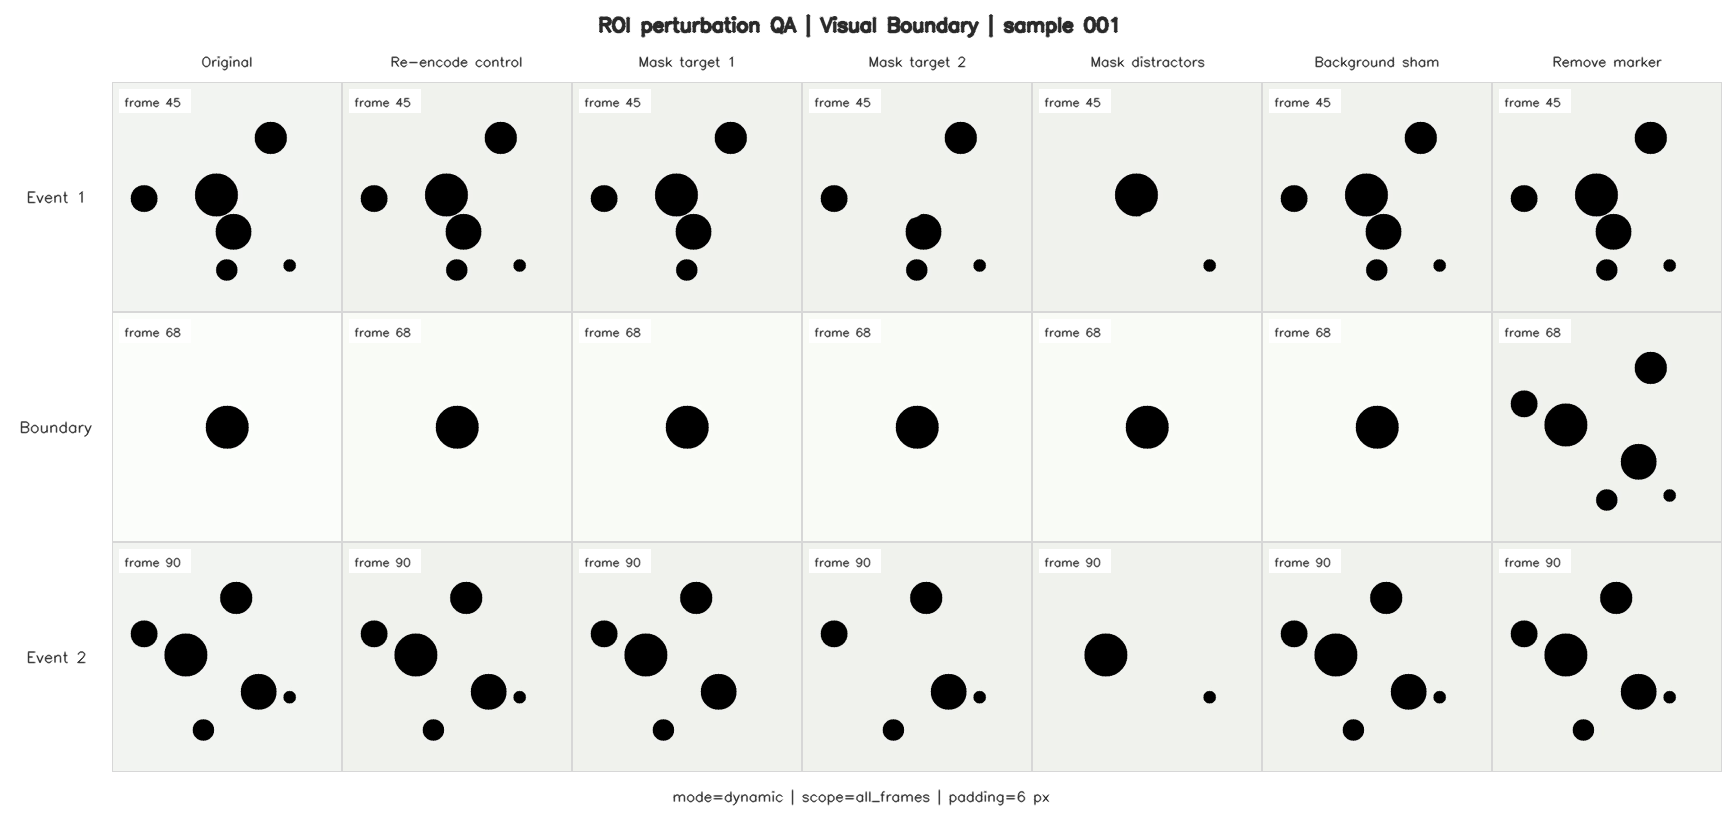

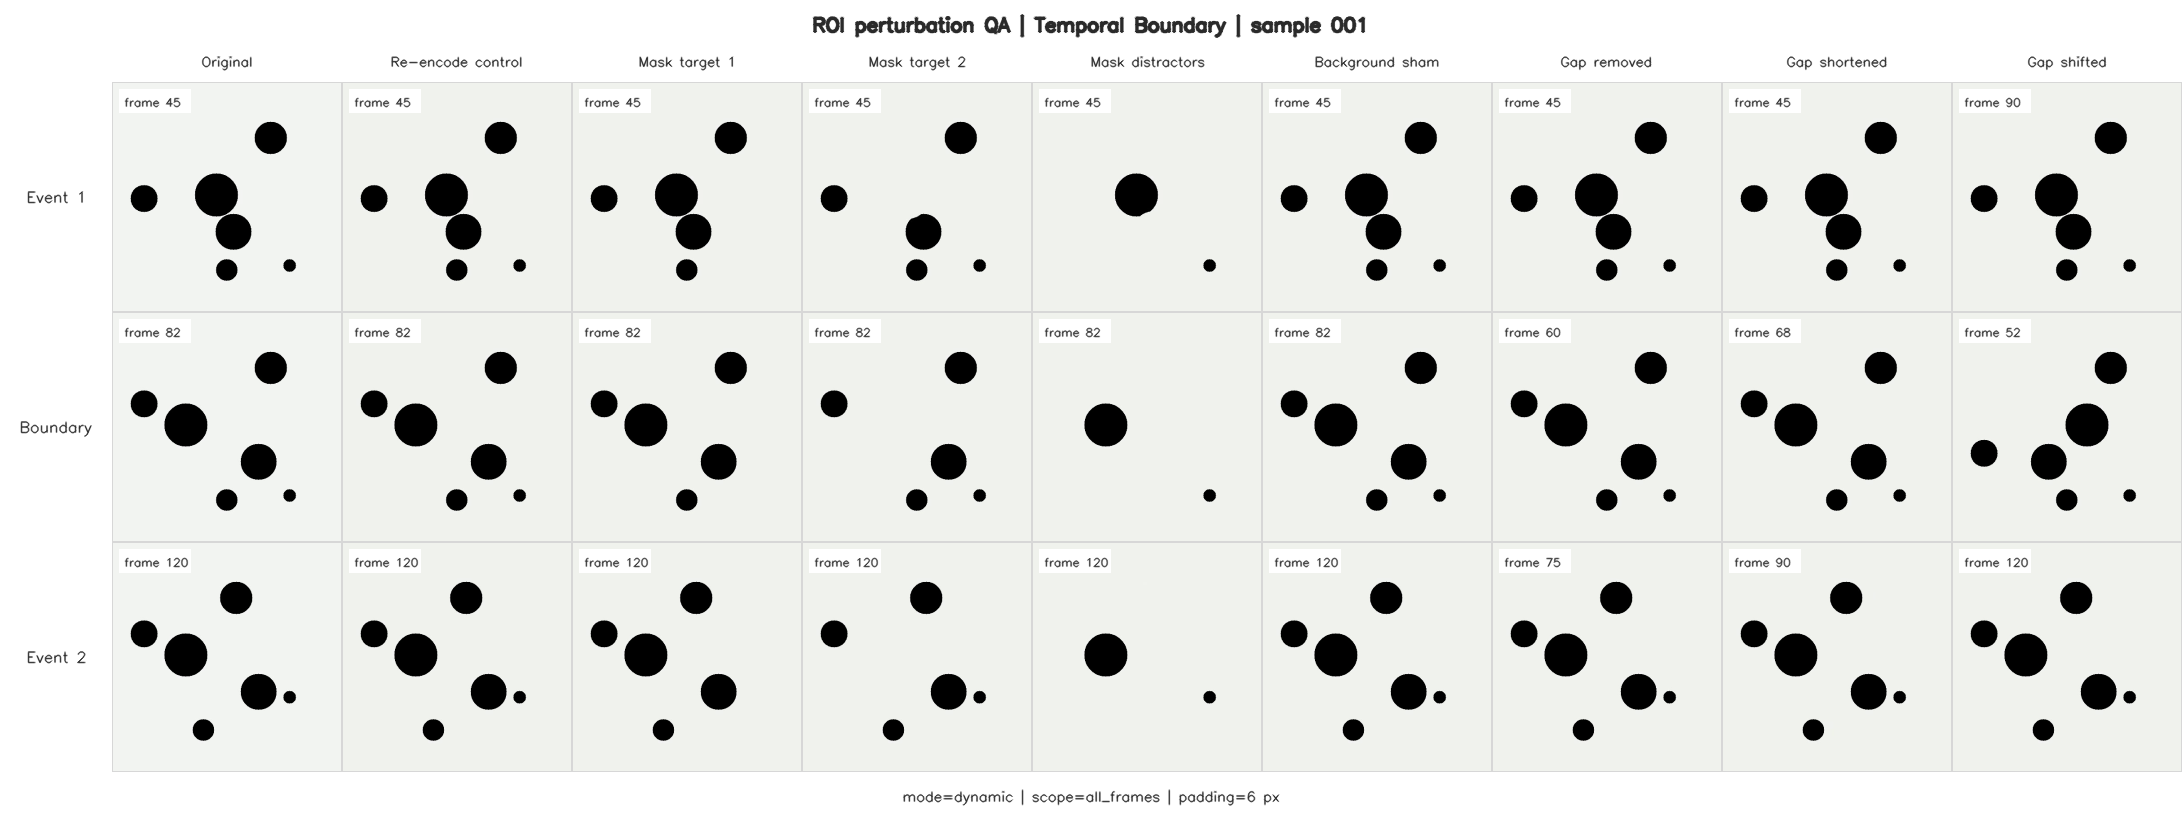

In [86]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

RUN_PERTURBATION_BUILD = True
RUN_PERTURBATION_EVAL = True
PERTURBATION_SOURCE = f"{SIZE_CLEAR_CONTRAST_ROOT}/L5_size_only_clear_small_many/annotations.jsonl"
PERTURBATION_MAX_BASE_SAMPLES = 4  # technical pilot; increase only after control checks pass
PERTURBATION_TYPES = (
    "original,reencode_control,mask_target_1,mask_target_2,mask_distractors,"
    "mask_background_control,remove_visual_marker,gap_removed,gap_shortened,gap_shifted"
)
ROI_MASK_PADDING = 6
ROI_MASK_SCOPE = "all_frames"  # use motion_window to isolate motion evidence

def run_streaming(command, label):
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"{label} failed with exit code {return_code}; see the log above.")

if RUN_PERTURBATION_BUILD:
    run_streaming([
        "python", "scripts/make_roi_perturbation_dataset.py",
        "--annotation_path", PERTURBATION_SOURCE,
        "--output_root", PERTURBATION_ROOT,
        "--max_base_samples", str(PERTURBATION_MAX_BASE_SAMPLES),
        "--perturbations", PERTURBATION_TYPES,
        "--mask_padding", str(ROI_MASK_PADDING),
        "--mask_mode", "dynamic",
        "--mask_scope", ROI_MASK_SCOPE,
        "--sham_reference", "distractors",
        "--sham_clearance", "4",
        "--sham_max_path_relative_error", "0.10",
    ], "ROI perturbation build")
    for preview_condition in ["visual_boundary", "temporal_boundary"]:
        preview_path = f"{PERTURBATION_ANALYSIS_DIR}/roi_qa_{preview_condition}.png"
        subprocess.run([
            "python", "scripts/visualize_roi_perturbations.py",
            "--annotation_path", f"{PERTURBATION_ROOT}/annotations.jsonl",
            "--condition", preview_condition,
            "--output_path", preview_path,
        ], check=True)
        display(Image(filename=preview_path))

if RUN_PERTURBATION_EVAL:
    perturbation_annotation = Path(PERTURBATION_ROOT) / "annotations.jsonl"
    if not perturbation_annotation.exists():
        raise FileNotFoundError("Build and inspect the ROI perturbation dataset first.")
    subprocess.run([
        "python", "scripts/run_eval.py",
        "--annotation_path", f"{PERTURBATION_ROOT}/annotations.jsonl",
        "--model_name", MODEL_NAME,
        "--model_revision", MODEL_REVISION,
        "--seed", str(EVAL_SEED),
        "--deterministic",
        "--attn_implementation", ATTN_IMPLEMENTATION,
        "--dataset_name", "l5_clear_small_many_perturbation",
        "--output_dir", RESULT_DIR,
    ], check=True)
    subprocess.run([
        "python", "scripts/analyze_results.py",
        "--input", RESULT_DIR,
        "--dataset_name_prefix", "l5_clear_small_many_perturbation",
        "--latest_per_dataset",
        "--output_dir", PERTURBATION_ANALYSIS_DIR,
        "--plots",
    ], check=True)
if not RUN_PERTURBATION_BUILD and not RUN_PERTURBATION_EVAL:
    print("Set RUN_PERTURBATION_BUILD = True to generate/preview masks, then RUN_PERTURBATION_EVAL = True to evaluate them.")


### Attention ROI Probe

This probes the final prompt position whose logits predict the first A/B answer token. A prefix cache keeps the query to one token, and the script requires parity with standard greedy generation. Cases are selected from archived behavioural outcomes rather than annotation order; temporal-versus-visual contrasts are retained as atomic matched bundles. ROI attribution uses fractional cell overlap, averages every sampled frame within each temporal patch, preserves mixed phase weights, and records padding sensitivity.

The plots now separate visual-normalised attention mass from area-normalised enrichment. Target labels include semantic identity, mover order, and grammatical subject role. After the GPU probe, a CPU-only Phase 0 analysis writes layer-level and early/middle/late target contrast tables. Enrichment is not total attention, and attention remains a qualitative mechanism probe to interpret alongside perturbation results.


In [87]:
import json
import subprocess
from pathlib import Path
from IPython.display import Image, display

RUN_ATTENTION_ROI_PROBE = True
ATTENTION_ANNOTATIONS = f"{SIZE_CLEAR_CONTRAST_ROOT}/L5_size_only_clear_small_many/annotations.jsonl"
ATTENTION_CASE_MANIFEST = str(
    Path(ATTENTION_OUTPUT_PATH).with_name("l5_clear_small_many_cases.jsonl")
)
ATTENTION_MAX_SAMPLES = 8

if RUN_ATTENTION_ROI_PROBE:
    main_runs = sorted(Path(RESULT_DIR).glob(
        "*/l5_feature_ablation_v1_size_clear_contrast_L5_size_only_clear_small_many/*/raw_results.jsonl"
    ))
    perturbation_runs = sorted(Path(RESULT_DIR).glob(
        "*/l5_clear_small_many_perturbation/*/raw_results.jsonl"
    ))
    if not main_runs or not perturbation_runs:
        raise FileNotFoundError(
            "Run the clear-small-many main evaluation and perturbation evaluation first."
        )
    subprocess.run([
        "python", "scripts/select_attention_cases.py",
        "--annotation_path", ATTENTION_ANNOTATIONS,
        "--main_results", str(main_runs[-1]),
        "--perturbation_results", str(perturbation_runs[-1]),
        "--output_path", ATTENTION_CASE_MANIFEST,
        "--max_video_pairs", str(ATTENTION_MAX_SAMPLES // 2),
    ], check=True)
    attention_command = [
        "python", "scripts/probe_attention_roi.py",
        "--annotation_path", ATTENTION_CASE_MANIFEST,
        "--output_path", ATTENTION_OUTPUT_PATH,
        "--visualization_dir", ATTENTION_VISUALIZATION_DIR,
        "--model_name", MODEL_NAME,
        "--expected_transformers_version", "5.9.0",
        "--model_revision", MODEL_REVISION,
        "--seed", str(EVAL_SEED),
        "--deterministic",
        "--attn_implementation", "eager",
        "--max_samples", str(ATTENTION_MAX_SAMPLES),
        "--roi_padding", "8",
        "--roi_assignment", "overlap",
        "--roi_padding_sensitivity", "0,4,8,12",
        "--parity_atol", "0.25",
        "--visualization_layer", "-1",
        "--head_reduction", "mean",
        "--empty_cache_each_sample",
    ]
    process = subprocess.Popen(
        attention_command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(
            f"Attention probe failed with exit code {return_code}; see the full log above."
        )
    rows = json.loads(Path(ATTENTION_OUTPUT_PATH).read_text())
    for row in rows[:3]:
        print(
            row.get("eval_id"),
            "prediction=", row.get("prediction"),
            "archived_match=", row.get("prediction_match"),
            "standard_token_match=", (row.get("decision_query") or {}).get("standard_first_token_match"),
            "max_logit_diff=", (row.get("decision_query") or {}).get("standard_logits_max_abs_diff"),
            "top10_overlap=", (row.get("decision_query") or {}).get("standard_top10_token_overlap"),
            "video_attention=", row.get("selected_layer_visual_attention_fraction"),
            "spatial_roi=", row.get("spatial_roi_attention"),
        )
    for figure_path in sorted(Path(ATTENTION_VISUALIZATION_DIR).glob("*.png"))[:6]:
        display(Image(filename=str(figure_path)))
else:
    print("Set RUN_ATTENTION_ROI_PROBE = True to run a small attention/ROI probe.")


Set RUN_ATTENTION_ROI_PROBE = True to run a small attention/ROI probe.


### Phase 0 Attention Metric Decomposition

This CPU-only step can be rerun from an existing attention JSON without loading Qwen or using an A100. It separates total/all-token attention share, visual-normalised ROI mass, effective token-area share, mean attention per effective token, and area-normalised enrichment. It also writes Target 1 versus Target 2 layer and fixed early/middle/late contrast tables. This partition was specified before expanding to Phase 1 stimuli and remains fixed for subsequent analyses.


In [88]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

RUN_ATTENTION_PHASE0_ANALYSIS = (
    RUN_ATTENTION_ROI_PROBE or Path(ATTENTION_OUTPUT_PATH).is_file()
)

if RUN_ATTENTION_PHASE0_ANALYSIS and Path(ATTENTION_OUTPUT_PATH).is_file():
    subprocess.run([
        "python", "scripts/analyze_attention_roi.py",
        "--input_path", ATTENTION_OUTPUT_PATH,
        "--output_dir", ATTENTION_ANALYSIS_DIR,
    ], check=True)
    subprocess.run([
        "python", "scripts/visualize_attention_roi.py",
        "--input_path", ATTENTION_OUTPUT_PATH,
        "--output_dir", ATTENTION_VISUALIZATION_DIR,
        "--project_root", "/content/vlm-event-boundary",
    ], check=True)
    print("Phase 0 tables:", sorted(path.name for path in Path(ATTENTION_ANALYSIS_DIR).glob("*")))
    contrast_figures = sorted(Path(ATTENTION_VISUALIZATION_DIR).glob("*_layer_target_contrasts.png"))
    for figure_path in contrast_figures[:4]:
        display(Image(filename=str(figure_path)))
elif RUN_ATTENTION_PHASE0_ANALYSIS:
    print("Phase 0 requested, but ATTENTION_OUTPUT_PATH does not contain an attention JSON.")
else:
    print("Phase 0 skipped: the small attention probe is disabled and no archived JSON is configured.")


Phase 0 skipped: the small attention probe is disabled and no archived JSON is configured.


### Phase 1 Matched Feature Attention Calibration

This is the first expanded attention run. It selects four shared base stimuli across full, color-only, shape-only, and size-only; retains all four boundary conditions and both mirrored prompts; balances which target moves first; and checks that motion trajectories and event timing are structurally identical across feature variants. The default run contains 128 attention rows. Per-row plots are disabled to control storage; three aggregate mass-versus-enrichment figures are produced after the probe.


Phase 1 attention source=d32352e; resume=True; full-logit allclose=diagnostic; isolated failures=continue
Attention probe runtime: transformers=5.9.0, torch=2.11.0+cu128, device=NVIDIA A100-SXM4-40GB, memory=39.5 GB, cache_api=next_sequence_length, rows=128
Resume checkpoint was incompatible and has been preserved at /content/vlm-event-boundary/analysis/attention/l5_feature_calibration_attention_incompatible_20260831_161115.json: Resumable attention output contains an eval_id outside the current selection: l5_full_sample_001_low_boundary_original
Loading Qwen/Qwen3-VL-8B-Instruct with attention implementation eager...

Loading weights: 100%|██████████| 750/750 [00:05<00:00, 131.81it/s]
Attention probe 1/128: l5_full_sample_005_low_boundary_original
qwen-vl-utils using torchcodec to read video.
Attention probe 2/128: l5_full_sample_005_low_boundary_swapped
Attention probe 3/128: l5_full_sample_005_temporal_boundary_original
Attention probe 4/128: l5_full_sample_005_temporal_boundary_swa

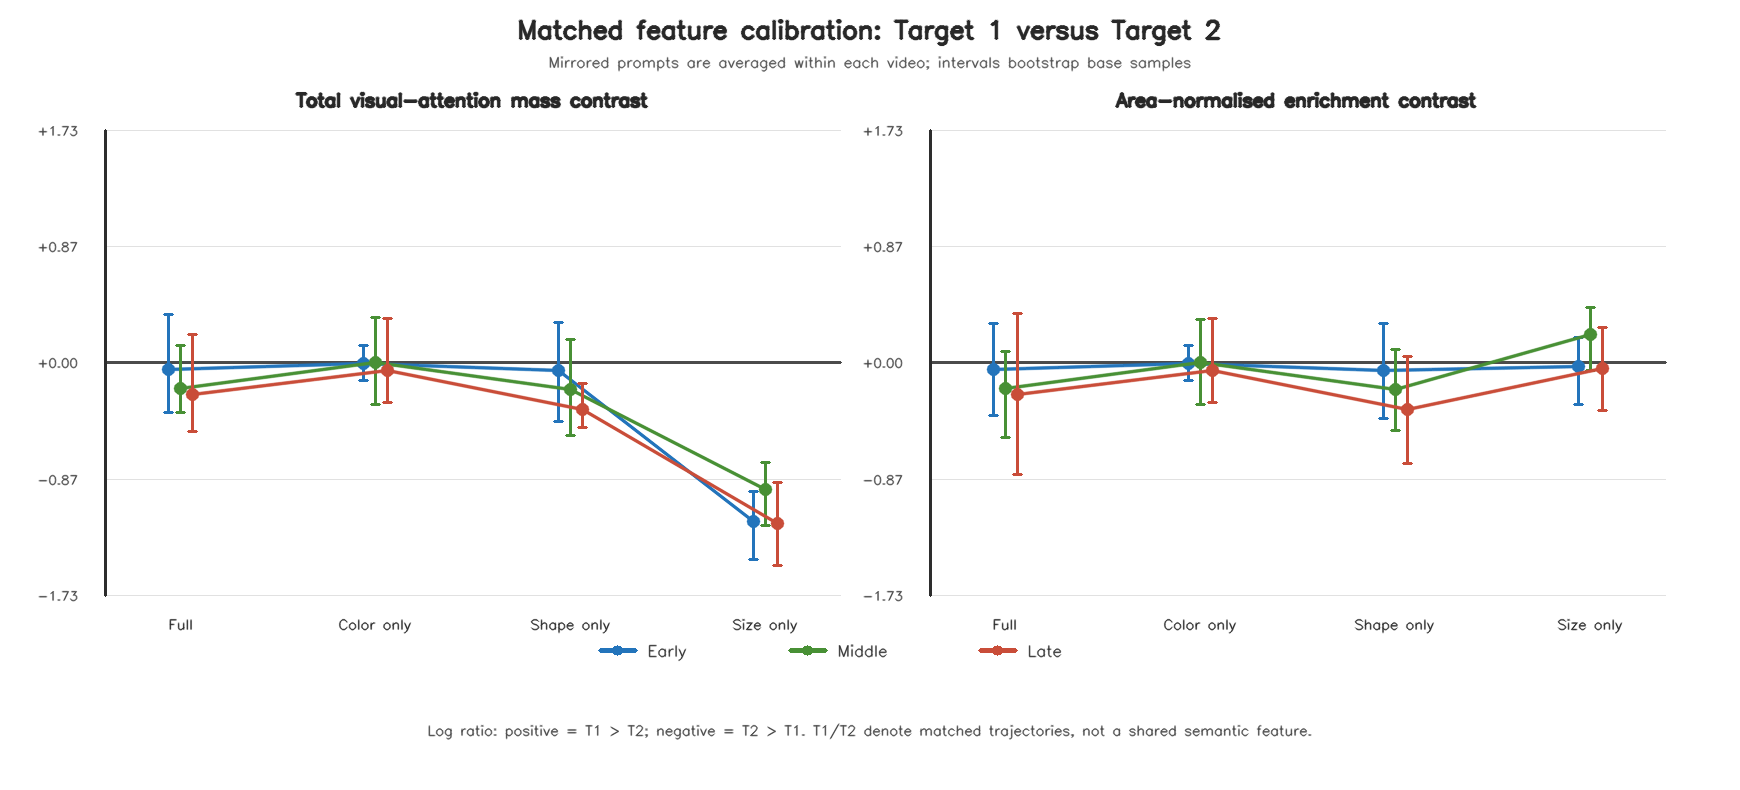

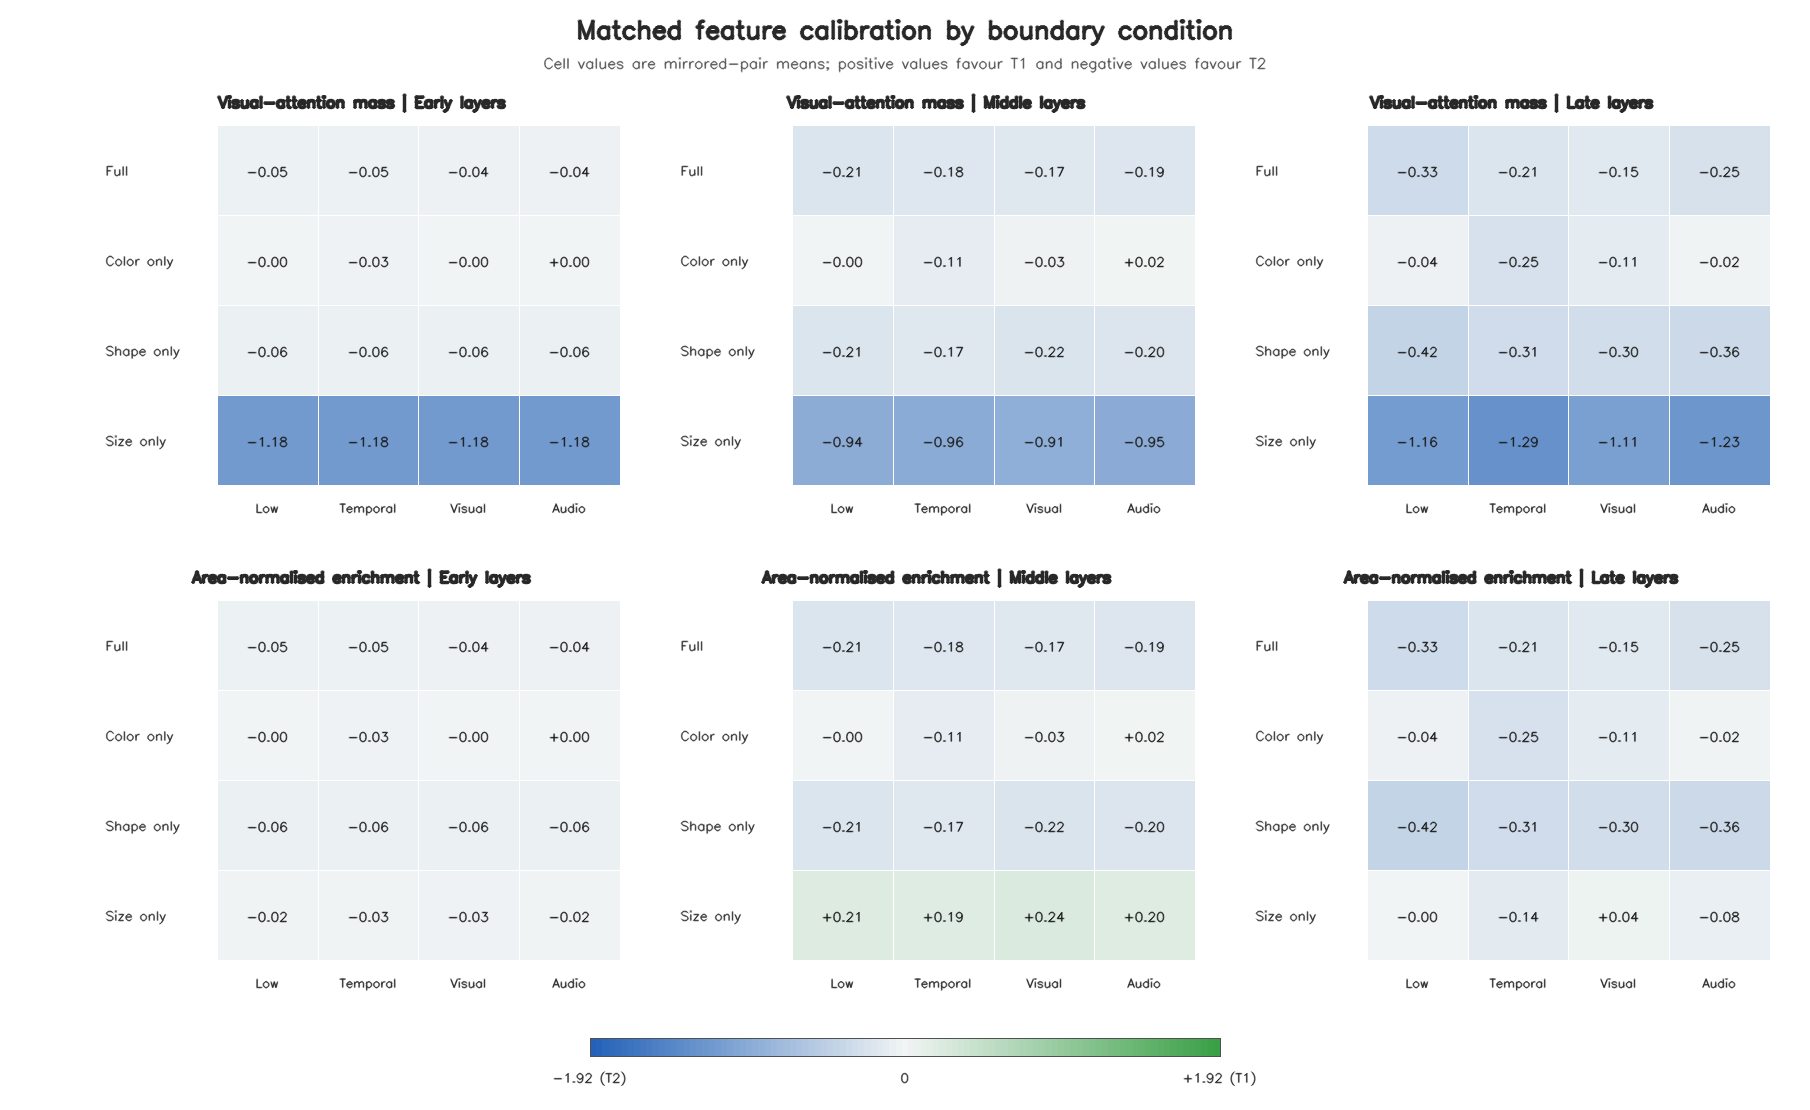

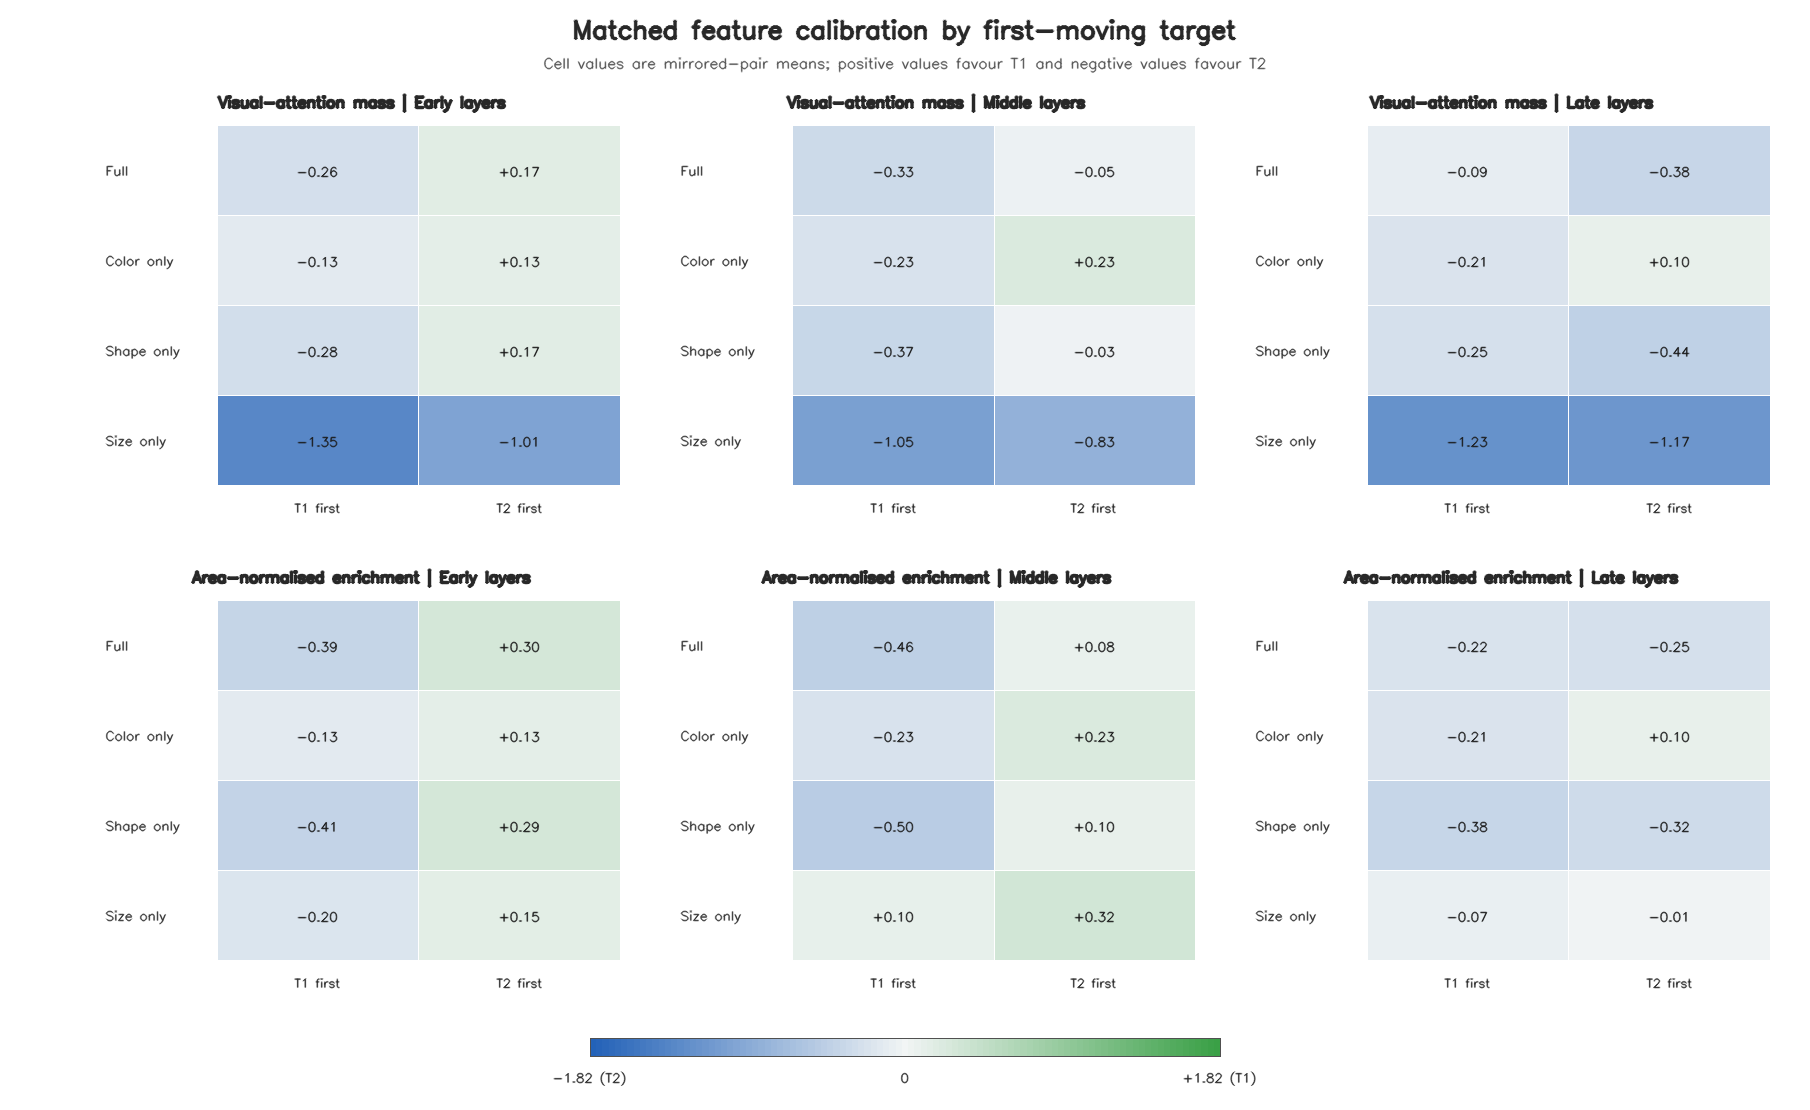

In [89]:
import json
import subprocess
from pathlib import Path
from IPython.display import Image, display
from scripts.common import slugify

RUN_FEATURE_ATTENTION_CALIBRATION = True

if RUN_FEATURE_ATTENTION_CALIBRATION:
    source_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], text=True
    ).strip()
    print(
        f"Phase 1 attention source={source_commit}; resume=True; "
        "full-logit allclose=diagnostic; isolated failures=continue"
    )
    model_result_root = Path(RESULT_DIR) / slugify(MODEL_NAME)
    feature_main_runs = []
    for variant_name in ABLATION_VARIANTS:
        matches = sorted(model_result_root.glob(
            f"l5_feature_ablation_v1_main_{variant_name}/*/raw_results.jsonl"
        ))
        if not matches:
            raise FileNotFoundError(
                f"Missing main evaluation for {variant_name}. Run the Level 5 feature evaluation first."
            )
        feature_main_runs.append(matches[-1])

    selection_command = [
        "python", "scripts/select_feature_attention_cases.py",
        "--annotation_root", ABLATION_ROOT,
        "--main_results", *[str(path) for path in feature_main_runs],
        "--output_path", FEATURE_ATTENTION_CASE_MANIFEST,
        "--base_samples", str(FEATURE_ATTENTION_BASE_SAMPLES),
    ]
    subprocess.run(selection_command, check=True)

    attention_command = [
        "python", "scripts/probe_attention_roi.py",
        "--annotation_path", FEATURE_ATTENTION_CASE_MANIFEST,
        "--output_path", FEATURE_ATTENTION_OUTPUT_PATH,
        "--model_name", MODEL_NAME,
        "--expected_transformers_version", "5.9.0",
        "--seed", str(EVAL_SEED),
        "--deterministic",
        "--attn_implementation", "eager",
        "--max_samples", str(FEATURE_ATTENTION_MAX_SAMPLES),
        "--roi_padding", "8",
        "--roi_assignment", "overlap",
        "--roi_padding_sensitivity", "0,4,8,12",
        "--parity_atol", "0.25",
        "--no-require_standard_logits_match",
        "--minimum_standard_top10_overlap", "0.8",
        "--minimum_standard_logits_cosine_similarity", "0.999",
        "--visualization_layer", "-1",
        "--head_reduction", "mean",
        "--empty_cache_each_sample",
        "--resume",
        "--continue_on_error",
        "--no-plots",
    ]
    if MODEL_REVISION:
        attention_command.extend(["--model_revision", MODEL_REVISION])
    process = subprocess.Popen(
        attention_command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="")
    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(
            f"Feature attention calibration failed with exit code {return_code}."
        )

    subprocess.run([
        "python", "scripts/analyze_attention_roi.py",
        "--input_path", FEATURE_ATTENTION_OUTPUT_PATH,
        "--output_dir", FEATURE_ATTENTION_ANALYSIS_DIR,
    ], check=True)
    selection_summary = Path(FEATURE_ATTENTION_CASE_MANIFEST).with_name(
        f"{Path(FEATURE_ATTENTION_CASE_MANIFEST).stem}_summary.json"
    )
    print("Selection audit:", json.loads(selection_summary.read_text()))
    parity_summary = Path(FEATURE_ATTENTION_OUTPUT_PATH).with_name(
        f"{Path(FEATURE_ATTENTION_OUTPUT_PATH).stem}_summary.json"
    )
    print("Probe parity and runtime:", json.loads(parity_summary.read_text()))
    for figure_name in [
        "feature_stage_mass_vs_enrichment.png",
        "feature_boundary_mass_vs_enrichment.png",
        "feature_first_mover_mass_vs_enrichment.png",
    ]:
        display(Image(filename=str(Path(FEATURE_ATTENTION_ANALYSIS_DIR) / figure_name)))
else:
    print("Set RUN_FEATURE_ATTENTION_CALIBRATION = True to run the 128-row matched calibration.")


## Download Timestamped Experiment Archive

Run this after an experiment. It packages all saved evaluation results, analyses, and ablation annotations into a timestamped ZIP and downloads it to your local computer. Videos are excluded to keep the archive manageable.


In [90]:
from datetime import datetime
import json
from pathlib import Path
import subprocess
import zipfile
from google.colab import files

project_root = Path("/content/vlm-event-boundary")
source_commit = subprocess.check_output(
    ["git", "-C", str(project_root), "rev-parse", "HEAD"], text=True
).strip()
attention_output = Path(globals().get("ATTENTION_OUTPUT_PATH", ""))
attention_figure_dir = Path(globals().get("ATTENTION_VISUALIZATION_DIR", ""))
attention_analysis_dir = Path(globals().get("ATTENTION_ANALYSIS_DIR", ""))
feature_attention_output = Path(globals().get("FEATURE_ATTENTION_OUTPUT_PATH", ""))
feature_attention_manifest = Path(globals().get("FEATURE_ATTENTION_CASE_MANIFEST", ""))
feature_attention_analysis = Path(globals().get("FEATURE_ATTENTION_ANALYSIS_DIR", ""))
perturbation_root = Path(globals().get("PERTURBATION_ROOT", ""))
perturbation_analysis = Path(globals().get("PERTURBATION_ANALYSIS_DIR", ""))
perturbation_runs = list(
    Path(RESULT_DIR).glob("*/l5_clear_small_many_perturbation/*/raw_results.jsonl")
)
missing_probe_artifacts = []

if globals().get("RUN_ATTENTION_ROI_PROBE", False):
    attention_case_manifest = Path(globals().get("ATTENTION_CASE_MANIFEST", ""))
    if not attention_case_manifest.is_file():
        missing_probe_artifacts.append(str(attention_case_manifest))
    if not attention_output.is_file():
        missing_probe_artifacts.append(str(attention_output))
    attention_summary = attention_output.with_name(f"{attention_output.stem}_summary.json")
    if not attention_summary.is_file():
        missing_probe_artifacts.append(str(attention_summary))
    if not attention_figure_dir.is_dir() or not list(attention_figure_dir.glob("*.png")):
        missing_probe_artifacts.append(f"{attention_figure_dir}/*.png")
    for filename in [
        "layer_roi_metrics.csv",
        "layer_target_contrasts.csv",
        "stage_target_contrasts.csv",
        "attention_archive_audit.csv",
        "summary.json",
    ]:
        path = attention_analysis_dir / filename
        if not path.is_file():
            missing_probe_artifacts.append(str(path))
if globals().get("RUN_FEATURE_ATTENTION_CALIBRATION", False):
    feature_required = [
        feature_attention_manifest,
        feature_attention_manifest.with_name(f"{feature_attention_manifest.stem}_summary.json"),
        feature_attention_output,
        feature_attention_output.with_name(f"{feature_attention_output.stem}_summary.json"),
        feature_attention_output.with_name(f"{feature_attention_output.stem}_config.json"),
    ]
    feature_required.extend(
        feature_attention_analysis / filename
        for filename in [
            "layer_roi_metrics.csv",
            "layer_target_contrasts.csv",
            "stage_target_contrasts.csv",
            "paired_stage_target_contrasts.csv",
            "feature_stage_summary.csv",
            "feature_boundary_stage_summary.csv",
            "feature_mover_stage_summary.csv",
            "feature_prompt_stage_summary.csv",
            "feature_pair_outcome_stage_summary.csv",
            "attention_archive_audit.csv",
            "summary.json",
            "feature_stage_mass_vs_enrichment.png",
            "feature_boundary_mass_vs_enrichment.png",
            "feature_first_mover_mass_vs_enrichment.png",
        ]
    )
    for path in feature_required:
        if not path.is_file():
            missing_probe_artifacts.append(str(path))
if globals().get("RUN_PERTURBATION_BUILD", False):
    for filename in ["annotations.jsonl", "manifest.json", "perturbation_stats.jsonl"]:
        path = perturbation_root / filename
        if not path.is_file():
            missing_probe_artifacts.append(str(path))
    for condition in ["visual_boundary", "temporal_boundary"]:
        preview_path = perturbation_analysis / f"roi_qa_{condition}.png"
        if not preview_path.is_file():
            missing_probe_artifacts.append(str(preview_path))
if globals().get("RUN_PERTURBATION_EVAL", False):
    if not perturbation_runs:
        missing_probe_artifacts.append(
            f"{RESULT_DIR}/*/l5_clear_small_many_perturbation/*/raw_results.jsonl"
        )
    perturbation_summary = perturbation_analysis / "summary.json"
    if not perturbation_summary.is_file():
        missing_probe_artifacts.append(str(perturbation_summary))

if missing_probe_artifacts:
    raise FileNotFoundError(
        "Optional probes were enabled but their outputs are missing. "
        "Run the corresponding probe cells successfully before archiving:\n- "
        + "\n- ".join(missing_probe_artifacts)
    )

attention_figures = (
    list(attention_figure_dir.glob("*.png")) if attention_figure_dir.is_dir() else []
)
feature_probe_summary_path = feature_attention_output.with_name(
    f"{feature_attention_output.stem}_summary.json"
)
feature_probe_summary = (
    json.loads(feature_probe_summary_path.read_text())
    if feature_probe_summary_path.is_file()
    else {}
)
probe_status = {
    "roi_build_requested": bool(globals().get("RUN_PERTURBATION_BUILD", False)),
    "roi_eval_requested": bool(globals().get("RUN_PERTURBATION_EVAL", False)),
    "attention_requested": bool(globals().get("RUN_ATTENTION_ROI_PROBE", False)),
    "attention_analysis_requested": bool(globals().get("RUN_ATTENTION_PHASE0_ANALYSIS", False)),
    "feature_attention_calibration_requested": bool(
        globals().get("RUN_FEATURE_ATTENTION_CALIBRATION", False)
    ),
    "feature_attention_expected_rows": globals().get("FEATURE_ATTENTION_MAX_SAMPLES"),
    "feature_attention_completed_rows": feature_probe_summary.get("rows"),
    "feature_attention_resumed_rows": feature_probe_summary.get("resumed_rows"),
    "feature_attention_failed_rows": feature_probe_summary.get("failed_rows"),
    "feature_attention_failed_eval_ids": feature_probe_summary.get("failed_eval_ids", []),
    "feature_attention_analysis_file_count": (
        len(list(feature_attention_analysis.glob("*")))
        if feature_attention_analysis.is_dir() else 0
    ),
    "perturbation_run_count": len(perturbation_runs),
    "attention_figure_count": len(attention_figures),
    "attention_analysis_table_count": (
        len(list(attention_analysis_dir.glob("*.csv")))
        if attention_analysis_dir.is_dir() else 0
    ),
}
archive_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
archive_path = Path("/content") / f"vlm_event_boundary_results_{archive_timestamp}.zip"
manifest = {
    "created_at": archive_timestamp,
    "source_commit": source_commit,
    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION or None,
    "eval_seed": EVAL_SEED,
    "deterministic": True,
    "attention_implementation": ATTN_IMPLEMENTATION,
    "ladder_version": DATASET_VERSION,
    "ablation_version": globals().get("ABLATION_VERSION"),
    "optional_probes": probe_status,
}

with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    archive.writestr("archive_manifest.json", json.dumps(manifest, indent=2))
    for folder in [Path(RESULT_DIR), project_root / "analysis"]:
        if folder.exists():
            for path in folder.rglob("*"):
                if path.is_file():
                    archive.write(path, path.relative_to(project_root))
    ablation_root = Path(globals().get("ABLATION_ROOT", ""))
    if ablation_root.exists():
        for pattern in ["annotations.jsonl", "config.json", "README.md"]:
            for path in ablation_root.rglob(pattern):
                archive.write(path, path.relative_to(project_root))
    for extra_data_root in [project_root / "data" / "diagnostics", project_root / "data" / "perturbations"]:
        if extra_data_root.exists():
            for pattern in ["annotations.jsonl", "manifest.json", "perturbation_stats.jsonl"]:
                for path in extra_data_root.rglob(pattern):
                    archive.write(path, path.relative_to(project_root))

print("Optional probe status:", json.dumps(probe_status, indent=2))
print(f"Created {archive_path} ({archive_path.stat().st_size / 1024 / 1024:.1f} MB)")
files.download(str(archive_path))


Optional probe status: {
  "roi_build_requested": true,
  "roi_eval_requested": true,
  "attention_requested": false,
  "attention_analysis_requested": false,
  "feature_attention_calibration_requested": true,
  "feature_attention_expected_rows": 128,
  "feature_attention_completed_rows": 127,
  "feature_attention_resumed_rows": 0,
  "feature_attention_failed_rows": 1,
  "feature_attention_failed_eval_ids": [
    "l5_color_only_sample_008_temporal_boundary_original"
  ],
  "feature_attention_analysis_file_count": 14,
  "perturbation_run_count": 2,
  "attention_figure_count": 0,
  "attention_analysis_table_count": 0
}
Created /content/vlm_event_boundary_results_20260831_170944.zip (15.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>